In [1]:
#imported packages
import arff
import re
import urllib.parse
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.inspection import permutation_importance
import joblib
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.neural_network import MLPClassifier
import requests
import ssl
import socket
from bs4 import BeautifulSoup
from urllib.parse import urlparse


In [2]:
with open('Training Dataset.arff', 'r') as f:
    dataset = arff.load(f)
data = list(dataset['data'])
attributes = list(dataset['attributes'])

df = pd.DataFrame(data, columns=[attr[0] for attr in attributes])
df = df.dropna(axis=1)

In [3]:
#axis=1 means drop columns
X = df.drop('Result', axis=1).astype(float)
y=df['Result'].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 67, stratify=y)
print(f"X train data: {X_train.shape[0]}")
print(f"X test data: {X_test.shape[0]}")

X train data: 8844
X test data: 2211


In [4]:
#Gaussian NB Init
GNB = GaussianNB()
GNB.fit(X_train, y_train)
GNB_predictions = GNB.predict(X_test)
GNB_score = accuracy_score(y_test, GNB_predictions)
print (f"GNB accuracy: {GNB_score}")

GNB accuracy: 0.5893260967887833


In [5]:
#KNN init
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
knn_predictions = knn.predict(X_test)
knn_score = accuracy_score(y_test, knn_predictions)
print (f"KNN accuracy: {knn_score}")

KNN accuracy: 0.9439167797376753


In [6]:
#Decision Tree init
tree_model = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth = 15,
    min_samples_leaf = 3,
    min_samples_split = 18,
    random_state = 67
)
tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)
tree_score = accuracy_score(y_test, tree_predictions)
print (f"Decision Tree Accuracy: {tree_score}")

Decision Tree Accuracy: 0.9466304839439168


In [7]:
rf_model = RandomForestClassifier(
    n_estimators = 497,
    max_features = 'sqrt',
    max_depth = 15,
    min_samples_leaf = 1,
    min_samples_split = 14,
    random_state=67,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_score = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy Score: {rf_score}")

Random Forest Accuracy Score: 0.9620081411126187


In [8]:
#multi-layer perceptrion neural network init
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 100),  
    activation='tanh',             
    solver='adam',                 
    max_iter=290,                  
    random_state=67                
)
mlp_model.fit(X_train, y_train)
mlp_predictions = mlp_model.predict(X_test)
mlp_score = accuracy_score(y_test, mlp_predictions)
print (f"MLP Accuracy: {mlp_score}")

MLP Accuracy: 0.9696969696969697


In [9]:
#create dictionary of results for ease of use in later cells
results = {
    "Gaussian NB": {"y_pred": GNB_predictions,    "model": GNB},
    "KNN": {"y_pred": knn_predictions,    "model": knn},
    "Decision Tree": {"y_pred": tree_predictions,   "model": tree_model},
    "MLP": {"y_pred": mlp_predictions,    "model": mlp_model},
    "Random Forest": {"y_pred": rf_predictions,    "model": rf_model}
}

In [10]:
#Hyperparam tuning (random search) on KNN

In [11]:
#Hyoerparam tuning (random search) on decision tree
param_dist_dt = {
    'max_depth': [None, 3, 5, 10, 15],'min_samples_split': randint(2, 20), 'min_samples_leaf': randint(1, 10), 'criterion':['gini', 'entropy']}
random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=67),
    param_distributions=param_dist_dt,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=67,
    n_jobs=-1
)
random_search_dt.fit(X_train, y_train)
print(f"Best Parameters: {random_search_dt.best_params_}")
print(f"Best F1 Score: {random_search_dt.best_score_:.4f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 3, 'min_samples_split': 18}
Best F1 Score: 0.9526


In [12]:
param_dist_rf = {
    'n_estimators': randint(100, 1000),
    'max_depth': [None, 3, 5, 10, 15],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2'],
}
random_search_rf = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state = 67, n_jobs=-1),
    param_distributions = param_dist_rf,
    n_iter = 10,
    cv = 3,
    random_state = 67,
    scoring = 'f1',
    n_jobs = -1
)
random_search_rf.fit(X_train, y_train)
print(f"Best Parameters: {random_search_rf.best_params_}")
print(f"Best F1 Score: {random_search_rf.best_score_:.4f}")

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 14, 'n_estimators': 497}
Best F1 Score: 0.9612


In [13]:
#Hyperparam tuning (random search) on decision tree
#param_dist_mlp = {
    #'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    #'activation': ['relu', 'tanh'],
    #'solver': ['adam', 'sgd'],
    #'max_iter': randint(200, 500),
#}
#random_search_mlp = RandomizedSearchCV(
    #estimator=MLPClassifier(random_state=67),
    #param_distributions=param_dist_mlp,
    #n_iter=20,
    #scoring='f1',
    #random_state=67,
    #n_jobs=-1
#)
#random_search_mlp.fit(X_train, y_train)
#print(f"Best Parameters: {random_search_mlp.best_params_}")
#print(f"Best F1 Score: {random_search_mlp.best_score_:.4f}")

In [14]:
#Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (100, 100), 'max_iter': 290, 'solver': 'adam'}
#Best F1 Score: 0.9702

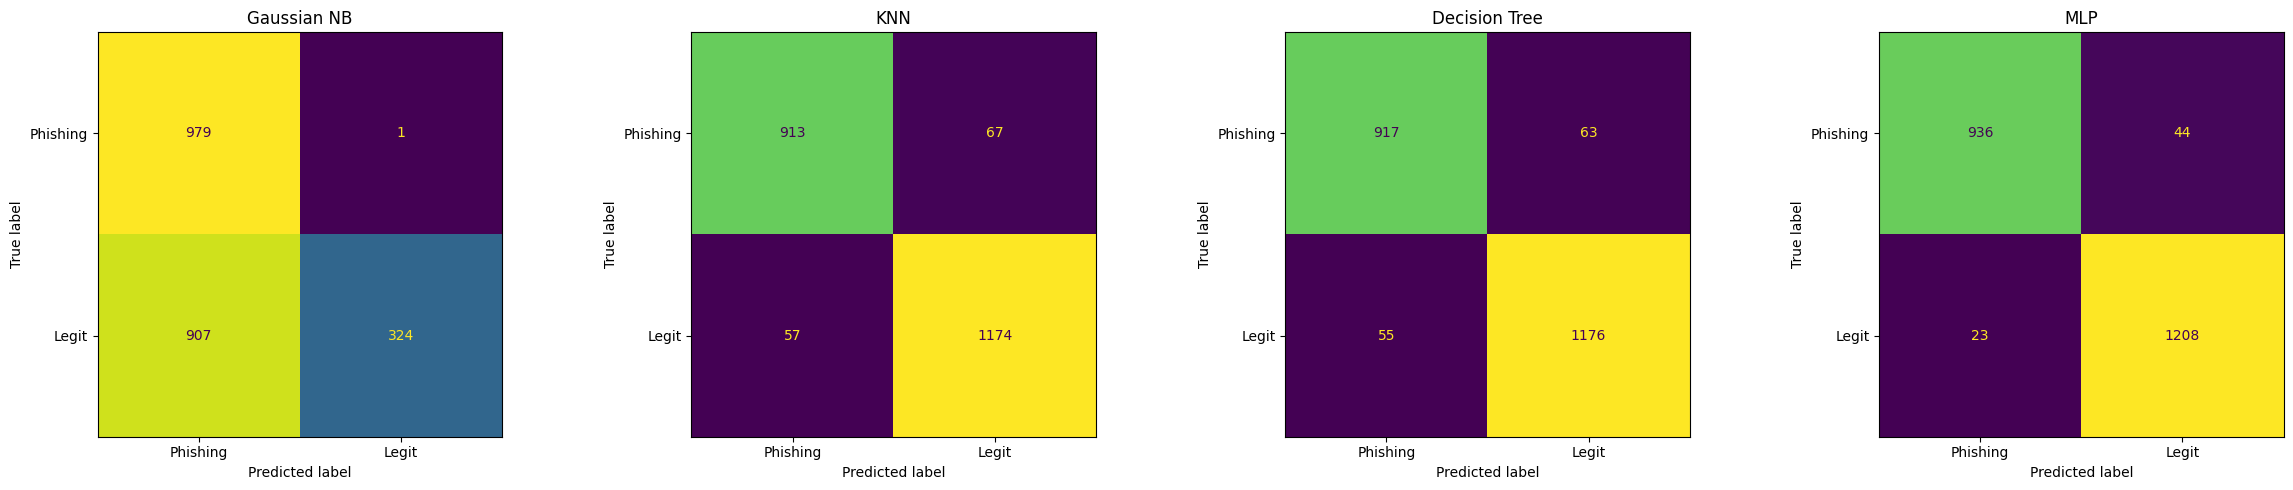

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
#for each plot frame, model name, and data within each model
#in zip(current plot frame, data in plot frame)...
for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Phishing", "Legit"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
#cross validation
#IMPORTANT!!! : Skip this step in future runs, takes too long to compile
#cross validation for MLP propogation
for name, result in results.items():
    if name == "Neural Network":
        # already have this from tuning
        print(f"{name}: Mean F1 = {random_search_mlp.best_score_:.4f} (from tuning)")
    else:
        cv_scores = cross_val_score(result["model"], X_scaled, y, cv=5, scoring='f1')
        print(f"{name}: Mean F1 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

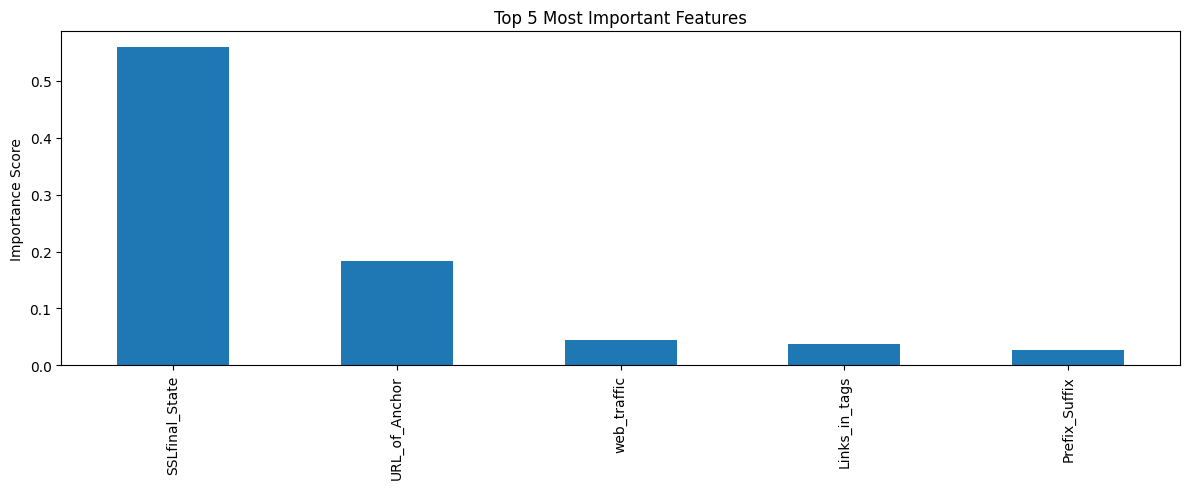

In [16]:
#feature importance
dt_model = results["Decision Tree"]["model"]
feature_names = df.drop('Result', axis=1).columns

importances = pd.Series(dt_model.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(5).plot(kind='bar', figsize=(12,5))
plt.title("Top 5 Most Important Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

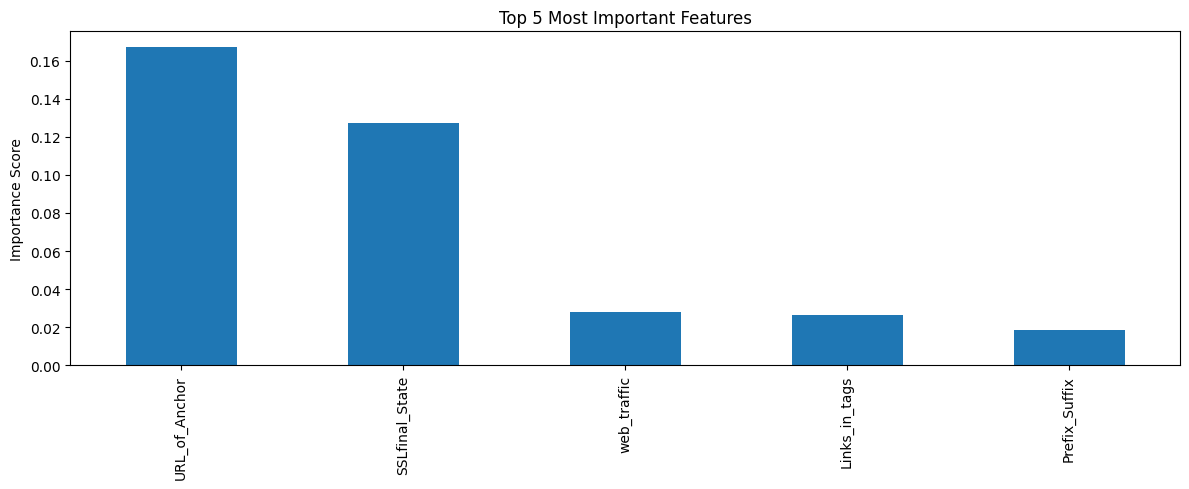

In [17]:
#permutation importance
dt_model = results["Decision Tree"]["model"]
feature_names = df.drop('Result', axis=1).columns

result = permutation_importance(dt_model, X_test, y_test, n_repeats=10, random_state=67)
importances = pd.Series(result.importances_mean, index=feature_names)

importances.sort_values(ascending=False).head(5).plot(kind='bar', figsize=(12,5))
plt.title("Top 5 Most Important Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [18]:
best_model = results["MLP"]["model"]
joblib.dump(best_model, 'phishing_classifier_v1.pkl')  
joblib.dump(scaler,     'scaler_v1.pkl')
print("V1 model saved")

V1 model saved


In [19]:
#check for redirection
def get_redirect(url):
    count = url.count('//')
    return -1 if count > 1 else 1

In [20]:
#check for risky ports
def get_port(url):
    port = urlparse(url).port
    risk_ports = [21, 22, 23, 135, 139, 80, 443, 445, 1433, 1521, 3306, 3389]
    if port is None:
        return 1
    elif port in risk_ports:
        return -1
    else:
        return 1

In [21]:
#check if hostname is present in URl path
def get_abnormal_url(url):
    hostname = urlparse(url).netloc
    return 1 if hostname in url else -1

In [22]:
def get_dns_record(url):
    try:
        domain = urlparse(url).netloc
        if domain.startswith('www.'):
            domain = domain[4:]
        #check if hostname can be resolved to IP, if not 
        #domain has no DNS record
        socket.gethostbyname(domain)
        return 1
    except socket.gaierror:
        return -1

In [23]:
def fetch_page(url):
    #common headers
    headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    try:
        response = requests.get(url, headers=headers, timeout=5)

        #make sure response is successful
        if response.status_code < 400:
            return response.text
        else:
            return None
            
    except (requests.exceptions.Timeout, requests.exceptions.ConnectionError, requests.exceptions.RequestException):
        return None
        

In [24]:
def get_ssl_state(url):
    try:
        hostname = urlparse(url).netloc

        #retrieve everything before the port number if present in the url
        if ':' in hostname:
            hostname = hostname.split(':')[0]

        #create valid certificate to be used to verify url certificate
        context = ssl.create_default_context()

        #open connection then perform SSL handshake
        with socket.create_connection((hostname, 443), timeout=5) as sock:
            with context.wrap_socket(sock, server_hostname = hostname) as ssock:
                #retrieve server certification
                cert = ssock.getpeercert()

                if cert:
                    return 1
                else:
                    return 0
    #Default to suspicous for any other exceptions, -1 for timeouts or no HTTPS running on server
    except(socket.timeout, ConnectionRefusedError):
        return -1
    except (ssl.SSLCertVerificationError, ssl.SSLError, Exception):
        return 0
        #Open SSL connection to hostname
        #Retrieve certificate

In [33]:
def get_anchor_feature(url, page_html):
    page_domain = urlparse(url).netloc

    soup = BeautifulSoup(page_html, 'html.parser')

    anchors = soup.find_all('a')

    if len(anchors) == 0:
        return -1
    
    total = 0
    external_or_suspicous = 0

    for anchor in anchors:
        href = anchor.get('href')

        total += 1

        if not href or href == '#' or href.startswith('javascript:'):
            external_or_suspicous +=1
            continue

        href_domain = urlparse(href).netloc

        if href_domain == '':
            continue
        elif href_domain != page_domain:
            external_or_suspicous += 1

    if total == 0:
        return -1

    ratio = external_or_suspicous / total

    #according to UCI dataset:
    #less than 31% external links inside anchors is legit
    #31-67% internal is suspicous
    #67%+ is phishing
    if ratio < 0.31:
        return 1
    elif ratio < 0.67:
        return 0
    else:
        return -1

In [34]:
def get_request_url(url,page_html):
    page_domain = urlparse(url).netloc
    soup = BeautifulSoup(page_domain, "html.parser")
    resource_tags = [
        ('img',    'src'), 
        ('script', 'src'),     
        ('link',   'href'),    
        ('video',  'src'),   
        ('audio',  'src'),     
    ]
    total = 0
    external = 0

    for tag_name, attribute in resource_tags:
        tags = soup.find_all(tag_name)
        for tag in tags:
            resource_url = tag.get(attr)

            if not resource_url:
                continue

            total+=1

            resource_domain = urlparse(resource_url).netloc
            
            if resource_domain == '':
                continue
            elif resource_domain != page_domain:
                external += 1

    if total == 0:
        return 0

    ratio = external / total

    #according to UCI dataset:
    #less than 22% external links inside anchors is legit
    #32-61% internal is suspicous
    #61%+ is phishing
    if ratio < 0.22:
        return 1
    elif ratio < 0.61:
        return 0
    else:
        return -1

In [35]:
import whois
from datetime import datetime, timezone
def get_domain_age(url):
    try:
        #extract domain from url
        domain = urlparse(url).netloc
        if (domain.startswith('www.')):
            domain = domain[4:]
        #get domain creation date
        domain_info = whois.whois(domain)
        creation_date = domain_info.creation_date

        if creation_date is None:
            return -1

        #some instances were lists so get the lists formatted the same as the standard creation dates
        if isinstance (creation_date, list):
            creation_date = creation_date[0]

        if not isinstance(creation_date, datetime):
            return -1

        if creation_date.tzinfo is not None:
            # tzinfo being present means the datetime is timezone aware
            # timezone.utc gives current UTC time to match
            now = datetime.now(timezone.utc)
        else:
            #else use local time
            now = datetime.now()
            
        #format creation date
        age_in_days = (now - creation_date).days

        if age_in_days >= 180:
            return 1
        else: 
            return -1
    
    except Exception:
        return -1
        
    #date_distance = creation_datea

In [36]:
def extract_features(url):
    """
    Extract features from a raw URL string
    Make sure each feature matches the UCI database format
    -1 = phishing indicator
    0 = Suspect
    1 = Clean/Non-Phishing Indicator
    """
    features = {}
    try:
        parsed = urllib.parse.urlparse(url)
        domain = parsed.netloc
        path = parsed.path
    except:
        return None
     
    ip_pattern = re.compile(r'\d+\.\d+\.\d+\.\d+')
    features['having_IP_Address'] = -1 if ip_pattern.search(url) else 1

    url_len = len(url)
    if (url_len < 54):
        features['URL_Length'] = 1
    elif (url_len <=75):
        features['URL_Length'] = 0
    else:
        features['URL_Length'] = -1

    shorteners = r'bit\.ly|goo\.gl|tinyurl|ow\.ly|t\.co|is\.gd'
    features['Shortining_Service'] = -1 if re.search(shorteners, url) else 1

    features['having_At_Symbol'] = -1 if '@' in url else 1

    last_double_slash = url.rfind('//')
    features['double_slash_redirecting'] = -1 if last_double_slash > 7 else 1

    features['Prefix_Suffix'] = -1 if '-' in domain else 1

    dot_count = domain.count('.')
    if dot_count == 1:
        features['having_Sub_Domain'] = 1
    elif dot_count == 2:
        features['having_Sub_Domain'] = 0
    else:
        features['having_Sub_Domain'] = -1

    features['HTTPS_token'] = -1 if 'https' in domain.lower() else 1

    features['SSLfinal_State'] = get_ssl_state(url)

    features['age_of_domain'] = get_domain_age(url)

    features['Redirect'] = get_redirect(url)
    
    features['port'] = get_port(url)
    
    features['Abnormal_URL'] = get_abnormal_url(url)
    
    features['DNSRecord'] = get_dns_record(url)

    page_html = fetch_page(url)

    if page_html is not None:
        features['URL_of_Anchor'] = get_anchor_feature(url, page_html)
        features['Request_URL'] = get_request_url(url, page_html)
    else:
        #default to 'suspicous' if page couldn't be fetched
        features['URL_of_Anchor'] = 0
        features['Request_URL'] =  0
        
    return features

In [37]:
extractable_features = [
    'having_IP_Address',
    'URL_Length',
    'Shortining_Service',
    'having_At_Symbol',
    'double_slash_redirecting',
    'Prefix_Suffix',
    'having_Sub_Domain',
    'HTTPS_token',
    'SSLfinal_State',
    'age_of_domain',
    'URL_of_Anchor',
    'Request_URL',
    'Redirect',
    'port',
    'Abnormal_URL',
    'DNSRecord'
]

In [38]:
X_reduced = df[extractable_features].astype(float)
y_reduced = df['Result'].astype(int)

scaler_v2 = StandardScaler()
X_reduced_scaled = scaler_v2.fit_transform(X_reduced)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced_scaled, y_reduced,
    test_size=0.2,
    random_state=67,
    stratify=y_reduced
)

mlp_v2 = MLPClassifier(
    activation='tanh',
    hidden_layer_sizes=(100, 100),
    max_iter=500,
    solver='adam',
    random_state=67,
    early_stopping=True,
    n_iter_no_change=10
)

mlp_v2.fit(X_train_r, y_train_r)

#Save second iteration of model trained on less data
joblib.dump(mlp_v2,               'phishing_classifier_v2.pkl')
joblib.dump(scaler_v2,            'scaler_v2.pkl')
joblib.dump(extractable_features, 'feature_names_v2.pkl')
print("V2 model saved")

V2 model saved


In [31]:
# test the v2 model directly without the agent loop
test_url = "http://192.168.1.254/secure/login/paypal/verify"

# extract features
extracted = extract_features(test_url)

# build feature vector
feature_vector = [extracted.get(feat, 0) for feat in feature_names]
print("Feature vector:", feature_vector)

# scale
feature_df = pd.DataFrame([feature_vector], columns=feature_names)
feature_scaled = scaler.transform(feature_df)

# predict
prediction = model.predict(feature_scaled)[0]
proba = model.predict_proba(feature_scaled)[0]

print(f"Raw prediction: {prediction}")
print(f"Probabilities: {proba}")
print(f"Class order: {model.classes_}")

Feature vector: [-1, 1, 1, 1, 1, 1, -1, -1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0, 0]


NameError: name 'model' is not defined

In [39]:
#agent loop
model = joblib.load('phishing_classifier_v2.pkl')
scaler = joblib.load('scaler_v2.pkl')

feature_names = joblib.load('feature_names_v2.pkl')

def predict_url(url):
    if not url.startswith('http'):
        url = 'http://' + url    #add scheme if it is missing
    extracted = extract_features(url)

    if extracted is None:
        return 'Error, could not parse URL.'

    print("\n--- Feature Extraction Debug ---")
    for feat in feature_names:
        value = extracted.get(feat, "MISSING")
        status = "Extracted" if value != "MISSING" else "Missing"
        print(f"  {feat:35} {value}  {status}")
    print("--------------------------------\n")
    feature_vector = [extracted.get(feat, 0) for feat in feature_names]

    feature_df = pd.DataFrame([feature_vector], columns = feature_names)

    feature_scaled = scaler.transform(feature_df)

    prediction = model.predict(feature_scaled)[0]

    confidence = model.predict_proba(feature_scaled)[0]
    confidence_score = max(confidence) * 100

    #hard overrides for obvious phishing singles including:
    #raw IP in URL, no SSL + new domain, and deep subdomain + IP
    phishing_signals = [
        extracted.get('having_IP_Address') == -1,   
        extracted.get('SSLfinal_State') == -1 and extracted.get('age_of_domain') == -1,  
        extracted.get('having_Sub_Domain') == -1 and extracted.get('having_IP_Address') == -1 
    ]

    if any(phishing_signals):
        return -1, max(confidence_score, 75.0)

    return prediction, confidence_score

def run_agent():
    print ("Phishing URL Detector")
    print ("Type 'quit' to exit")

    while True:

        url = input("\nEnter URL to check: ").strip()

        if url.lower() == 'quit':
            break
        if not url:
            print ("Please enter a valid URL")
            continue
        
        result = predict_url(url)
    
        if isinstance(result, str):
            print (f"Error: {result}")
            continue
    
        prediction, confidence = result
    
        if prediction == -1:
            print (f"Phishing Detected. {confidence:.1f}% confident")
        else:
            print (f"Legitimate URL. {confidence:.1f}% confident")

run_agent()

Phishing URL Detector
Type 'quit' to exit



Enter URL to check:  google.com



--- Feature Extraction Debug ---
  having_IP_Address                   1  Extracted
  URL_Length                          1  Extracted
  Shortining_Service                  1  Extracted
  having_At_Symbol                    1  Extracted
  double_slash_redirecting            1  Extracted
  Prefix_Suffix                       1  Extracted
  having_Sub_Domain                   1  Extracted
  HTTPS_token                         1  Extracted
  SSLfinal_State                      1  Extracted
  age_of_domain                       1  Extracted
  URL_of_Anchor                       0  Extracted
  Request_URL                         0  Extracted
  Redirect                            1  Extracted
  port                                1  Extracted
  Abnormal_URL                        1  Extracted
  DNSRecord                           1  Extracted
--------------------------------

Legitimate URL. 100.0% confident



Enter URL to check:  https://netflix-login-update.com



--- Feature Extraction Debug ---
  having_IP_Address                   1  Extracted
  URL_Length                          1  Extracted
  Shortining_Service                  1  Extracted
  having_At_Symbol                    1  Extracted
  double_slash_redirecting            1  Extracted
  Prefix_Suffix                       -1  Extracted
  having_Sub_Domain                   1  Extracted
  HTTPS_token                         1  Extracted
  SSLfinal_State                      0  Extracted
  age_of_domain                       -1  Extracted
  URL_of_Anchor                       0  Extracted
  Request_URL                         0  Extracted
  Redirect                            1  Extracted
  port                                1  Extracted
  Abnormal_URL                        1  Extracted
  DNSRecord                           -1  Extracted
--------------------------------

Phishing Detected. 74.4% confident



Enter URL to check:  https://secure-ups-tracking-info.biz



--- Feature Extraction Debug ---
  having_IP_Address                   1  Extracted
  URL_Length                          1  Extracted
  Shortining_Service                  1  Extracted
  having_At_Symbol                    1  Extracted
  double_slash_redirecting            1  Extracted
  Prefix_Suffix                       -1  Extracted
  having_Sub_Domain                   1  Extracted
  HTTPS_token                         1  Extracted
  SSLfinal_State                      0  Extracted
  age_of_domain                       -1  Extracted
  URL_of_Anchor                       0  Extracted
  Request_URL                         0  Extracted
  Redirect                            1  Extracted
  port                                1  Extracted
  Abnormal_URL                        1  Extracted
  DNSRecord                           -1  Extracted
--------------------------------

Phishing Detected. 74.4% confident



Enter URL to check:  https://g00gle.com



--- Feature Extraction Debug ---
  having_IP_Address                   1  Extracted
  URL_Length                          1  Extracted
  Shortining_Service                  1  Extracted
  having_At_Symbol                    1  Extracted
  double_slash_redirecting            1  Extracted
  Prefix_Suffix                       1  Extracted
  having_Sub_Domain                   1  Extracted
  HTTPS_token                         1  Extracted
  SSLfinal_State                      0  Extracted
  age_of_domain                       1  Extracted
  URL_of_Anchor                       0  Extracted
  Request_URL                         0  Extracted
  Redirect                            1  Extracted
  port                                1  Extracted
  Abnormal_URL                        1  Extracted
  DNSRecord                           -1  Extracted
--------------------------------

Legitimate URL. 100.0% confident



Enter URL to check:  quit
